Source: https://github.com/AntoineGrimaldi/wassa/blob/main/2025-01-14_results_synthetic_data/2024-12-02_evolution_num_samples_static.ipynb
(Checked on Wed, Jan 29th)

In [ ]:
!pip install git+https://github.com/AntoineGrimaldi/wassa.git

  Cloning https://github.com/AntoineGrimaldi/wassa.git to /tmp/pip-req-build-zscotwim
  Running command git clone --filter=blob:none --quiet https://github.com/AntoineGrimaldi/wassa.git /tmp/pip-req-build-zscotwim
  Resolved https://github.com/AntoineGrimaldi/wassa.git to commit d14cc5aa33ac9c5acc3ca46c1d762ba8f4a55e65
  Preparing metadata (setup.py) ... done
  Created wheel for wassa: filename=wassa-1.0-py3-none-any.whl size=26183 sha256=d301f10609c913d4dbe195e4593830b22ba3f86dfb2db3f582364706b4f245cf
  Stored in directory: /tmp/pip-ephem-wheel-cache-h7ep45ht/wheels/37/fd/d7/4de77d51d51f161edce9a118a118d7037eba68e52daea728f7
Successfully built wassa


In [ ]:
! wget https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/ii_spike_times.npy
! wget https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/spike_times.npy
! wget https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/stim_label.npy

--2025-01-30 14:09:40--  https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/ii_spike_times.npy
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/bsotomayorg/Intro_HPC_Python/refs/heads/main/datasets/AllenData/ii_spike_times.npy [following]
--2025-01-30 14:09:41--  https://raw.githubusercontent.com/bsotomayorg/Intro_HPC_Python/refs/heads/main/datasets/AllenData/ii_spike_times.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3200128 (3.1M) [application/octet-stream]
Saving to: ‘ii_spike_times.npy’

ii_spike_times.npy  100%[===================>]   3.05M  --.

In [ ]:
import torch, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from wassa.dataset_generation import sm_generative_model, generate_dataset
from wassa.wassa_plots import plot_results_std, plot_SM, plot_colored_raster
from wassa.wassa_metrics import WassDist, correlation_latent_variables, correlation_kernels, kernels_diff, torch_cdf_loss
from wassa.wassa_utils import performance_as_a_function_of_number_of_epochs

from sklearn.model_selection import train_test_split

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

---

Data loading and formatting

In [ ]:
spike_times    = np.load("spike_times.npy")
ii_spike_times = np.load("ii_spike_times.npy")
stim_label     = np.load("stim_label.npy")

In [ ]:
np.min(spike_times), np.max(spike_times)

(1.556491042720154e-07, 0.09999947704864098)

In [ ]:
def get_SM(spike_times, ii_spike_times, T, nbins=100):
  # it assumes spike times are defined in [0, T]
  # T: window lenght (in seconds)
  M = ii_spike_times.shape[0]
  N = ii_spike_times.shape[1]
  mat = np.zeros(shape=(M, N, nbins))
  for i_M in range(M):
    for i_N in range(N):
      st = spike_times[ii_spike_times[i_M,i_N,0]:ii_spike_times[i_M,i_N,1]].copy()
      st = st*(nbins/T)
      mat[i_M, i_N, st.astype(int)] += 1
  return mat

In [ ]:
%%time
SM = get_SM(spike_times, ii_spike_times[:, :100,:], T=0.100, nbins=20)

CPU times: user 233 ms, sys: 8.28 ms, total: 242 ms
Wall time: 410 ms


In [ ]:
SM.shape # (num trials, num neurons, timesteps)

(200, 100, 20)

Text(0, 0.5, 'Neuron ID')

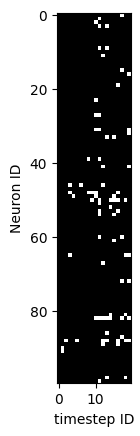

In [ ]:
# example of one raster
plt.imshow(SM[1], cmap='Grays_r')
plt.xlabel("timestep ID"); plt.ylabel("Neuron ID")

In [ ]:
num_trials, num_neurons, num_timesteps = SM.shape

---
WassA

In [ ]:
date = '2024-01-30'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Some attrs of `dataset_parameters` were modified, other I didnt get what to set.

In [ ]:
class dataset_parameters():
    seed = 666

    N_pre       = num_neurons   # (modified) number of neurons
    N_timesteps = num_timesteps # (modified) number of timesteps for the raster plot (in ms)
    N_samples   = num_trials    # (modified) total number of samples in the dataset

    N_delays   = 51 # (is this required?)                       number of timesteps in spiking motifs, must be a odd number for convolutions
    N_SMs      = 1  # (is this required?)                       number of structured spiking motifs
    N_involved = N_pre*torch.ones(N_SMs) # (is this required?)  number of neurons involved in the spiking motif
    avg_fr = 20 # (is this required?) average firing rate of the neurons (in Hz)
    std_fr = .1 # (is this required?) standard deviation for the firing rates of the different neurons
    frs = torch.normal(avg_fr, std_fr, size=(N_pre,)).abs() # (is this required?)
    freq_sms = 12*torch.ones(N_SMs) # (is this required?)  frequency of apparition of the different spiking motifs (in Hz)
    overlapping_sms = False # (is this required?)  possibility to have overlapping sequences

    temporal_jitter = 1  # (is this required?) temporal jitter for the spike generation in motifs
    dropout_proba = 0    # (is this required?) probabilistic participations of the different neurons to the spiking motif
    additive_noise = 0.1 # (is this required?) percentage of background noise/spontaneous activity
    warping_coef = 1     # (is this required?) coefficient for time warping

    def get_parameters(self):
        return f'{self.N_pre}_{self.N_delays}_{self.N_SMs}_{self.N_timesteps}_{self.N_samples}_{self.N_involved.mean()}_{self.avg_fr}_{self.freq_sms.mean()}_{self.overlapping_sms}_{self.temporal_jitter}_{self.dropout_proba}_{self.additive_noise}_{self.warping_coef}_{self.seed}'



`sm` is required in `train_and_plot` method.

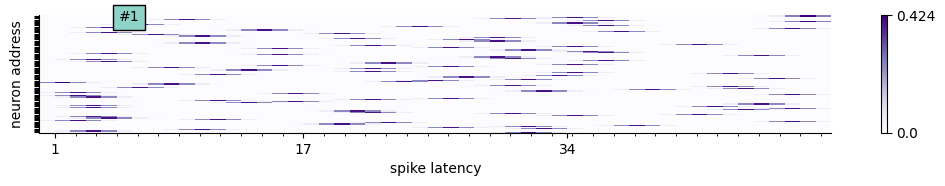

In [ ]:
sm = sm_generative_model(dataset_parameters, device = device)
plot_SM(sm.SMs);

In [ ]:
sm.SMs.shape

torch.Size([1, 100, 51])

In [ ]:
class training_parameters:
    kernel_size = (sm.opt.N_SMs, sm.opt.N_pre, sm.opt.N_delays)
    loss_type = 'mse'
    N_learnsteps = 1000
    learning_rate = .001
    penalty_type = None
    smoothwind = 20
    lambda_ = .1
    batch_size = None
    output = 'linear'
    do_bias = True
    zeros = 'ignore'
    wass_order = 1
    weight_init = None
    if not penalty_type:
        lambda_ = 0
    elif penalty_type[:8] != 'smoothed':
        smoothwind = 0
    if lambda_ == 0:
        penalty_type = None
    def get_parameters(self):
        name = f'{self.loss_type}_{self.output}_{self.penalty_type}_{self.do_bias}_{self.kernel_size}_{self.N_learnsteps}_{self.learning_rate}_{self.lambda_}_{self.batch_size}_{self.smoothwind}'
        if self.loss_type == 'emd':
            name += f'_{self.zeros}_{self.wass_order}'
        return name

---
Training. Definition of datasets

In [ ]:
params_mse = training_parameters()
params_emd = training_parameters()
params_emd.loss_type = 'emd'

In [ ]:
SM.shape

(200, 100, 20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(SM, stim_label, test_size=0.4, random_state=0)

In [ ]:
X_train.shape, y_train.shape, np.unique(y_train, return_counts=True)

((120, 100, 20),
 (120,),
 (array([  0,  45,  90, 135]), array([31, 30, 27, 32])))

from numpy to torch

In [ ]:
trainset_input = torch.from_numpy(X_train)
testset_input  = torch.from_numpy(X_test)
testset_output = torch.from_numpy(y_test)

In [ ]:
from wassa.wassa_utils import train_and_plot

---

Not sure if these tensors are correct considering AE input format **(Ask Antoine)**

Note: consider (200 trials, 100 neurons, 20 timesteps) and test_size = 40%.

In [ ]:
trainset_input.shape

torch.Size([120, 100, 20])

In [ ]:
testset_input.shape

torch.Size([80, 100, 20])

In [ ]:
testset_output.shape

torch.Size([80])

In [ ]:
# these values correspond to the orientation value of drifting gratings stimuli
testset_output

tensor([  0, 135,  90,  45, 135, 135,   0,  90,   0, 135,  45,  90, 135, 135,
         45,   0,   0,  90,   0,  45, 135,  90,   0, 135,  45,  90, 135, 135,
         90,   0,   0,  45, 135,  90,   0, 135,  90,   0,  45,  90,  90,  45,
          0,  90, 135,  45,   0,  45,  90,  90,  45,  90, 135,  45,  90,   0,
          0, 135,   0,  45,  90,  45, 135,   0, 135,  45,  45, 135,  45,  45,
         90,  45,  90,  90,  90,  45,  90,   0,   0,  90])

In [ ]:
%%time
results = train_and_plot(
    sm, trainset_input, testset_input, testset_output, [params_mse], date=date, iteration = 0, device=device)

RuntimeError: Calculated padded input size per channel: (20). Kernel size: (51). Kernel size can't be greater than actual input size